In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M


In [4]:
df.shape

(105434, 11)

In [5]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105434 entries, 0 to 105433
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           105434 non-null  int64 
 1   experience_level    105434 non-null  object
 2   employment_type     105434 non-null  object
 3   job_title           105434 non-null  object
 4   salary              105434 non-null  int64 
 5   salary_currency     105434 non-null  object
 6   salary_in_usd       105434 non-null  int64 
 7   employee_residence  105434 non-null  object
 8   remote_ratio        105434 non-null  int64 
 9   company_location    105434 non-null  object
 10  company_size        105434 non-null  object
dtypes: int64(4), object(7)
memory usage: 8.8+ MB


In [7]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,105434.000000,1.054340e+05,105434.000000,105434.000000
mean,2024.188981,1.626908e+05,158018.514179,21.103249
std,0.669665,2.137236e+05,74401.714026,40.714744
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.064000e+05,106400.000000,0.000000
50%,2024.000000,1.471000e+05,147000.000000,0.000000
75%,2025.000000,1.997000e+05,199000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [8]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [9]:
df['salary_in_usd'].describe()

,salary_in_usd
count,105434.000000
mean,158018.514179
std,74401.714026
min,15000.000000
25%,106400.000000
50%,147000.000000
75%,199000.000000
max,800000.000000


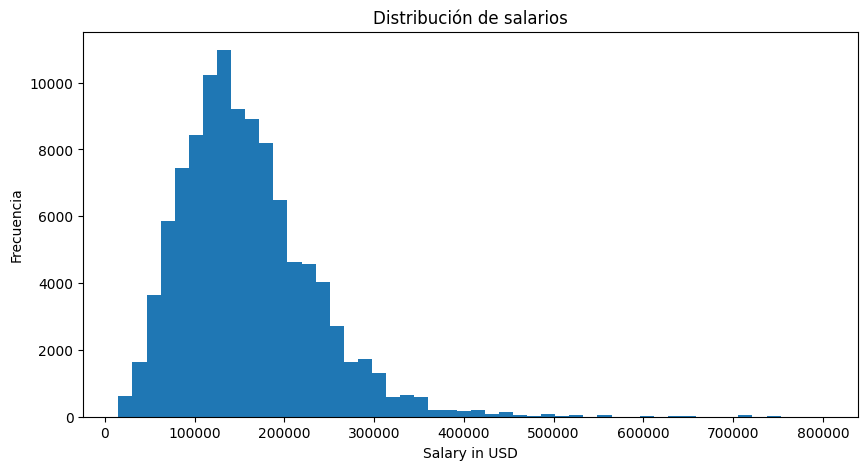

In [10]:
plt.figure(figsize=(10,5))
plt.hist(df['salary_in_usd'], bins=50)
plt.xlabel('Salary in USD')
plt.ylabel('Frecuencia')
plt.title('Distribución de salarios')
plt.show()

In [11]:
#¿El dataset está dominado por ciertos puestos?
df['job_title'].value_counts().head(10)

,count
job_title,
Data Scientist,14938
Data Engineer,12392
Software Engineer,11635
Data Analyst,10024
Machine Learning Engineer,7169
Engineer,6862
Manager,4686
Analyst,2882
Research Scientist,2833


In [12]:
#¿El dataset está dominado por EEUU? En ese caso, ¿representaria el mercado mundial?
df['company_location'].value_counts().head(10)

,count
company_location,
US,94834
CA,3987
GB,2962
AU,378
DE,311
NL,281
FR,278
LT,266
ES,229


In [13]:
#¿Hay más seniors que juniors? Podria inflar los salarios medios artificialmente
#EN → Entry
#MI → Mid
#SE → Senior
#EX → Executive
df['experience_level'].value_counts()

,count
experience_level,
SE,61396
MI,31802
EN,9938
EX,2298


OBSERVACIONES DATASET GLOBAL:
La mayoría de salarios están entre:

100k - 200k USD

pero hay unos pocos salarios extremadamente altos:

400k, 500k, incluso 800k

Eso crea una distribución asimétrica.

La media es: 158k

pero la mediana es: 147k

Cuando:

media > mediana

suele significar que:

✅ hay salarios extremos altos
✅ los outliers están inflando la media

El dataset presenta una distribución salarial sesgada hacia salarios altos. Algunos salarios extremos elevan artificialmente la media, por lo que usar únicamente el salario promedio podría llevar a conclusiones engañosas sobre el mercado laboral.

El dataset no representa todo el mercado tecnológico, está MUY dominado por EEUU.

Eso significa que:

-NO representa el mercado global

-Los salarios medios estarán inflados

-Las conclusiones estarán sesgadas hacia empresas americanas

Aunque el dataset contiene empresas de múltiples países, más del 90% de los registros pertenecen a Estados Unidos, lo que limita la representatividad global del análisis.

Además vemos esto en cuanto a la experiancia laboral:

SE → 61.396

y juniors:

EN → 9.938

Eso puede provocar que:

✅ el salario medio parezca más alto de lo real

✅ el mercado parezca más “lucrativo” de lo que es para perfiles junior

Por último, os puestos dominantes son:

Data Scientist
Data Engineer
Software Engineer

Eso significa que:

⚠️ las conclusiones NO aplican necesariamente a TODO el sector tecnológico.

Por ejemplo, faltan perfiles de:

QA, UX/UI, ciberseguridad, etc.

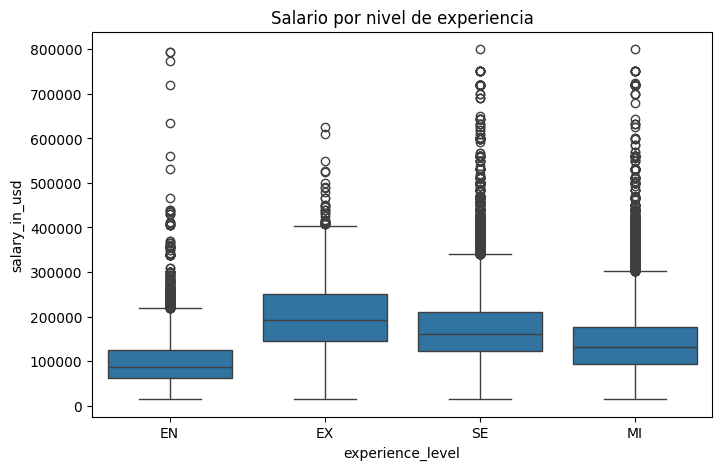

In [14]:
#¿Cuánto cambia el salario según experiencia?
df.groupby('experience_level')['salary_in_usd'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Salario por nivel de experiencia')
plt.show()

Se confirma que la experiencia afecta mucho al salario

Aunque la experiencia influye claramente en el salario, existe una gran variabilidad dentro de cada grupo, lo que sugiere que otros factores como país, tipo de empresa o especialización también tienen un fuerte impacto.

Hay una anomalía interesante:

SENIOR parece muy cercano a EXECUTIVE

Eso podría significar que el mercado tech paga muchísimo a seniors especializados

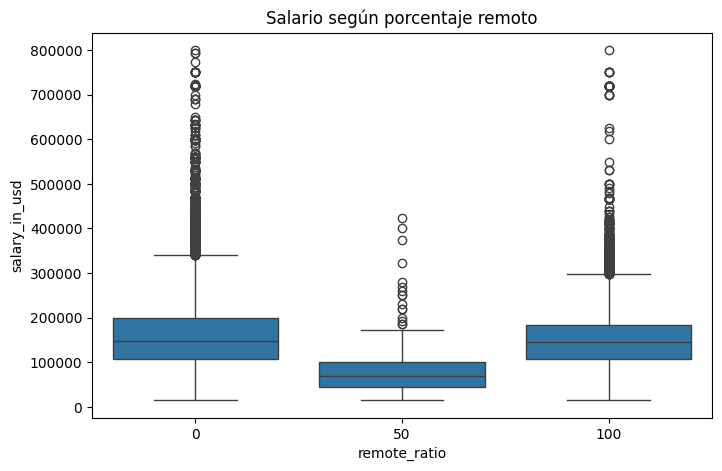

In [15]:
#Salario medio según remote_ratio
df.groupby('remote_ratio')['salary_in_usd'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)
plt.title('Salario según porcentaje remoto')
plt.show()

Parece que el trabajo híbrido tiene salarios más bajos, pero esto no tiene por qué ser una relación causal:

**Hipótesis muy probable**

Las empresas estadounidenses tech:

-pagan más

-ofrecen más remoto total

Mientras que empresas tradicionales:

-híbridas

-fuera de EEUU

-podrían pagar menos.

Entonces:

⚠️ quizá NO es el remoto lo que aumenta salarios

⚠️ quizá es el país o tipo de empresa

Sería una variable de confusión, aunque los trabajos totalmente remotos parecen asociados a salarios más altos, no puede afirmarse una relación causal directa, ya que otras variables como localización, seniority o tipo de empresa podrían estar influyendo simultáneamente.

In [16]:
df[['work_year', 'salary_in_usd', 'remote_ratio']].corr()

,work_year,salary_in_usd,remote_ratio
work_year,1.000000,0.031559,-0.099432
salary_in_usd,0.031559,1.000000,-0.058492
remote_ratio,-0.099432,-0.058492,1.000000


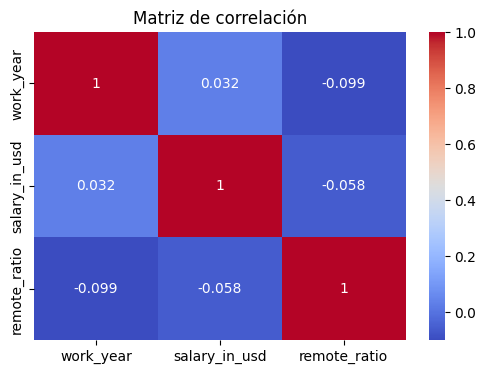

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[['work_year', 'salary_in_usd', 'remote_ratio']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de correlación')
plt.show()

In [18]:
#salario medio por puesto
df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Research Team Lead,450000.000000
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
AI Product Lead,325000.000000
Applied AI ML Lead,292500.000000
Head of Machine Learning,283573.545455
Director of Product Management,270407.142857
Machine Learning Performance Engineer,262500.000000
Engineering Manager,258278.709416


Los salarios más altos aparecen en puestos como:

-Research Team Lead

-AI Product Lead

-Head of Machine Learning

-Data Science Tech Lead

Los puestos mejor remunerados combinan liderazgo y especialización avanzada en IA o Machine Learning, lo que refleja la alta demanda del mercado por perfiles estratégicos y altamente técnicos

In [19]:
#salario por país
df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(50)

,salary_in_usd
company_location,
QA,300000.000000
VE,192500.000000
CZ,179411.500000
US,164040.772307
HK,155019.333333
IL,143757.941176
SA,139999.333333
EG,134407.317073
PR,131840.000000


A primera vista parece que Qatar paga muchísimo, pero…

Problema: probablemente hay muy pocos registros

Si un país tiene:

1 o 2 registros

la media puede ser engañosa. Asi que habría que filtrar los paises con suficientes datos.

In [20]:
#Contar registros por país
df['company_location'].value_counts().head(20)

,count
company_location,
US,94834
CA,3987
GB,2962
AU,378
DE,311
NL,281
FR,278
LT,266
ES,229


In [21]:
country_counts = df['company_location'].value_counts()

valid_countries = country_counts[country_counts > 100].index

df_filtered = df[df['company_location'].isin(valid_countries)]

In [22]:
#Salario medio fiable

df_filtered.groupby('company_location')['salary_in_usd'] \
.mean() \
.sort_values(ascending=False) \
.head(10)

,salary_in_usd
company_location,
US,164040.772307
CA,131375.746426
AU,129643.775132
IE,109481.980769
DE,104983.260450
GB,96440.795071
NL,79562.551601
FR,72921.482014
ES,65631.502183


Se filtraron países con muy pocos registros para evitar conclusiones poco fiables derivadas de tamaños de muestra reducidos.

EEUU NO solo domina el dataset en cantidad también tiene salarios especialmente altos. Esto probablemente eleva artificialmente el salario medio global, la percepción del mercado laboral y las expectativas salariales.

Hay diferencias salariales enormes entre países

US → 164k

GB → 96k

ES → 65k

Esto sugiere que la ubicación geográfica influye muchísimo y el mercado tecnológico NO es homogéneo por lo que comparar salarios globalmente puede ser engañoso.

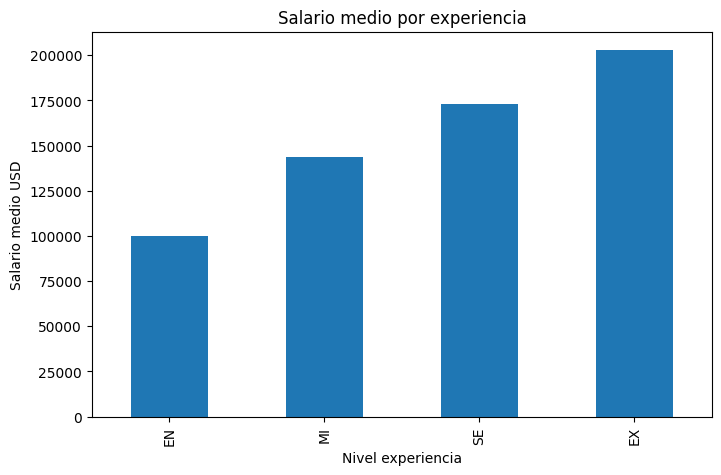

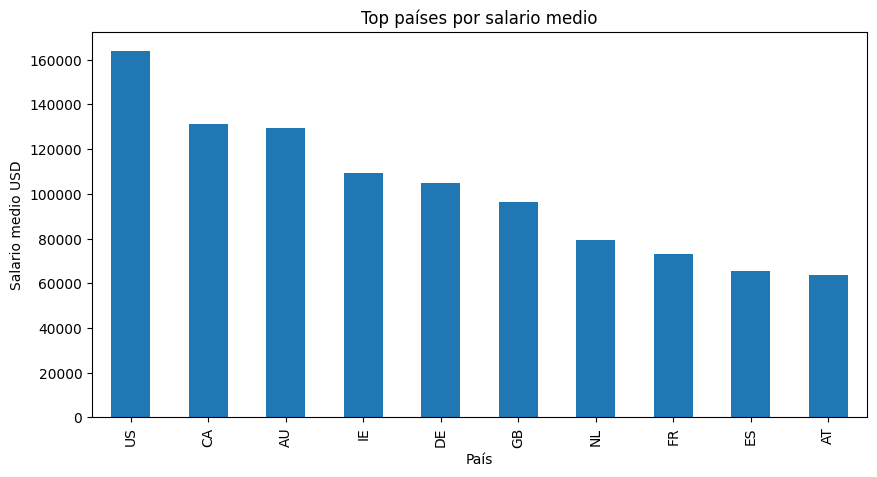

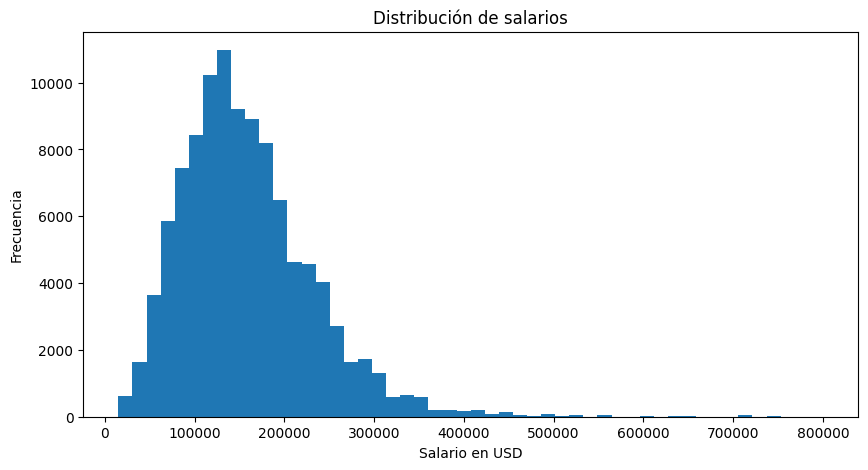

In [26]:
#VISUALIZACIÓN DE CONCLUSIONES:

#Salario por experiencia

experience_salary = (
    df.groupby('experience_level')['salary_in_usd']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
experience_salary.plot(kind='bar')

plt.title('Salario medio por experiencia')
plt.ylabel('Salario medio USD')
plt.xlabel('Nivel experiencia')
plt.show()

#Salario por paises

top_countries = (
    df_filtered.groupby('company_location')['salary_in_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title('Top países por salario medio')
plt.ylabel('Salario medio USD')
plt.xlabel('País')
plt.show()

#Distribucion salarial

plt.figure(figsize=(10,5))

plt.hist(df['salary_in_usd'], bins=50)

plt.title('Distribución de salarios')
plt.xlabel('Salario en USD')
plt.ylabel('Frecuencia')

plt.show()

1. Barplot salario vs experiencia

👉 demuestra impacto del seniority

2. Barplot países

👉 demuestra sesgo geográfico

3. Histograma salarios

👉 demuestra outliers y distribución desigual